# Obrada skupa podataka o temperaturi primenom DSP filtera

U ovom projektu analizira se skup podataka koji sadrži merenja temperature dobijena pomoću DS18B20 senzora u radijacionim kućištima i PT100 referentnog senzora. Merenja su prikupljana svake minute, pa je frekvencija odabiranja $f_s = 1/60$ Hz. To znači da je Nyquistova frekvencija $f_s/2 = 1/120$ Hz i da svi izbori granične frekvencije moraju da budu ispod te granice.

Na merenjima sa DS18B20 senzora prisutne su visokofrekventne oscilacije (šum), dok osnovni korisni signal predstavlja sporu promenu, odnosno temperaturni trend kroz više sati. Zato je cilj projekta da se prikaže uticaj šuma na temperaturni signal, izvrši analiza u vremenskom i frekvencijskom domenu, a zatim projektuju i uporede dva tipa digitalnih filtera u svrhu čišćenja signala:

- Butterworth niskopropusni IIR filter,
- FIR niskopropusni filter sa linearnom fazom projektovan prozorskom metodom.

Tokom izbora parametara vodili smo računa i o periodi odabiranja, i o tome da cutoff bude dovoljno nizak da potisne brze oscilacije, a dovoljno visok da sačuva spor temperaturni trend. Nakon filtriranja vrši se poređenje efikasnosti uklanjanja šuma, vernosti očuvanja trenda i uticaja faznog pomaka i grupnog kašnjenja.

## 1. Uvoz biblioteka

Na početku se uvoze biblioteke potrebne za numeričku obradu, učitavanje CSV fajla, prikaz grafika, Furijeovu analizu (FFT) i projektovanje digitalnih filtera.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.fft import fft, fftfreq

In [5]:
# Podešavanje prikaza grafika
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

## 2. Učitavanje i opis signala

U ovom delu se učitava CSV datoteka `temperature_measurements_2025.csv` koja sadrži merenja temperature sa rezolucijom od jednog uzorka na minut. Frekvencija odabiranja iznosi 1 minut po odbirku, odnosno $f_s = 1/60$ Hz. To je važna informacija za izbor cutoff-a, jer svaki cutoff mora ostati ispod Nyquistove frekvencije od $1/120$ Hz.

Za potrebe analize, kao zašumljeni signal ćemo uzeti `Temp1_corr`, a za proveru `ref_temp`. Pošto je vremenska osa iz CSV fajla stvarna, a ne idealizovana, u nastavku proveravamo i da li je korak između uzoraka zaista približno 60 s ili postoje prekidi u seriji.

Nakon učitavanja prikazuju se osnovne informacije o signalu i o periodi odabiranja:

- frekvencija odabiranja,
- broj odbiraka,
- trajanje signala u satima.

In [21]:
# Naziv CSV fajla
filename = "temperature_measurements_2025.csv"

# Učitavanje podataka.
# Vremenske oznake eksplicitno konvertujemo u UTC datetime da bi računanje ose bilo pouzdano.
df = pd.read_csv(filename)
df['time'] = pd.to_datetime(df['time'], errors='coerce', utc=True).dt.tz_convert(None)
df = df.dropna(subset=['time'])

# Sortiranje vrednosti po vremenu za svaki slučaj.
# Ovo obezbeđuje da signal i vremenska osa budu konzistentni.
df = df.sort_values('time').reset_index(drop=True)

# Izdvajanje signala
x_noisy_raw = df['Temp1_corr'].to_numpy()
x_ref = df['ref_temp'].to_numpy()

# Popunjavanje NaN vrednosti pre filtriranja i FFT analize.
# Interpolacija je ovde samo pripremni korak za DSP obradu, ne menja originalni signal.
x_noisy = pd.Series(x_noisy_raw).interpolate(method='linear', limit_direction='both').to_numpy()

# Vremenska osa iz stvarnih vremenskih oznaka, a ne samo iz broja uzoraka.
time_seconds = (df['time'] - df['time'].iloc[0]).dt.total_seconds().to_numpy()
t_hours = time_seconds / 3600.0

# Osnovni parametri signala
fs = 1.0 / 60.0  # frekvencija u Hz (1 odbirak svake minute -> 1/60 Hz)
N = len(x_noisy)
duration_hours = (df['time'].iloc[-1] - df['time'].iloc[0]).total_seconds() / 3600.0

sample_periods = df['time'].diff().dt.total_seconds().dropna().to_numpy()
print(f"Frekvencija odabiranja: {fs:.5f} Hz")
print(f"Broj odbiraka: {N}")
print(f"Broj NaN vrednosti u Temp1_corr: {np.isnan(x_noisy_raw).sum()}")
print(f"Trajanje signala: {duration_hours:.2f} sati")

if sample_periods.size > 0:
    max_step_deviation = np.max(np.abs(sample_periods - 60.0))
    print(f"Prosečan korak uzorkovanja: {sample_periods.mean():.2f} s")
    print(f"Maksimalno odstupanje od 60 s: {max_step_deviation:.2f} s")

Frekvencija odabiranja: 0.01667 Hz
Broj odbiraka: 300953
Broj NaN vrednosti u Temp1_corr: 13272
Trajanje signala: 5016.97 sati
Prosečan korak uzorkovanja: 60.01 s
Maksimalno odstupanje od 60 s: 3600.00 s


## 3. Prikaz signala u vremenskom domenu

Prikaz originalnog signala i referentnog senzora pre obrade omogućava da vizuelno potvrdimo postojanje visokofrekventnog šuma preko niskofrekventne komponente (dnevnog trenda).

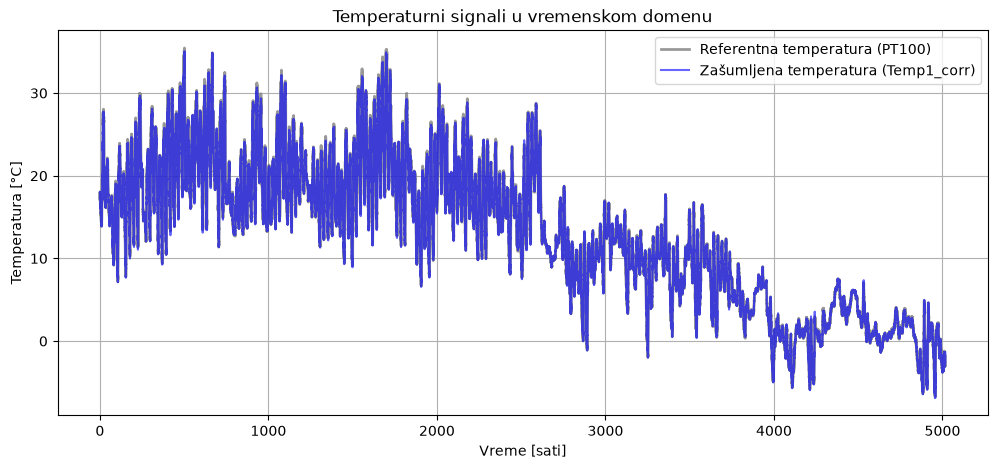

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(t_hours, x_ref, label='Referentna temperatura (PT100)', color='gray', alpha=0.8, linewidth=2)
plt.plot(t_hours, x_noisy, label='Zašumljena temperatura (Temp1_corr)', color='blue', alpha=0.6)
plt.title("Temperaturni signali u vremenskom domenu")
plt.xlabel("Vreme [sati]")
plt.ylabel("Temperatura [°C]")
plt.legend()
plt.show()

## 4. FFT analiza originalnog signala

Primenom Brze Furijeove transformacije (FFT) posmatramo frekvencijski sastav zašumljenog signala. Zbog izuzetno spore dinamike temperature, korisne komponente očekujemo na frekvencijama jako blizu 0 Hz (red veličine delova miliherca - mHz), dok će se komponente šuma prostirati u višem delu spektra.

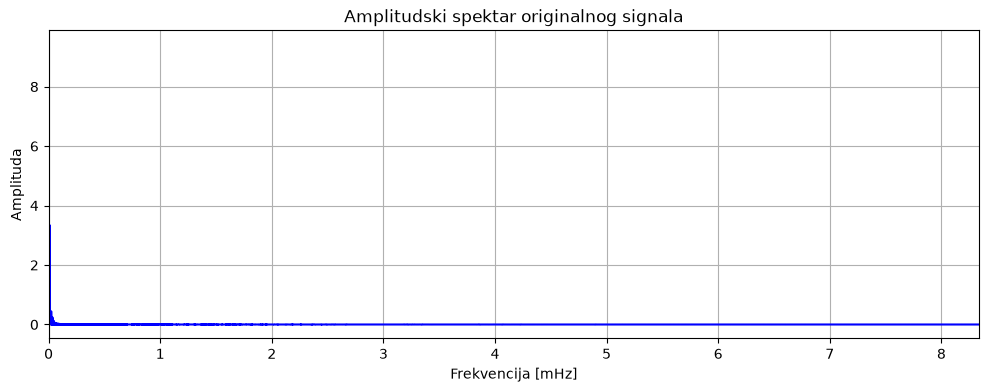

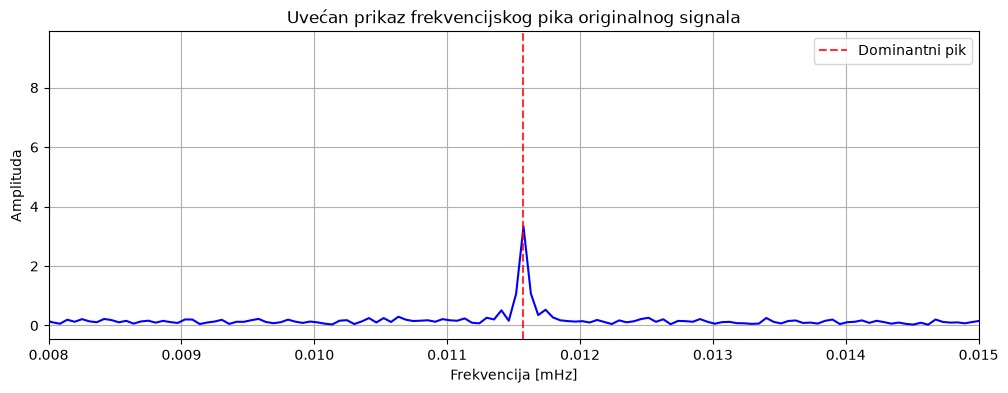

In [9]:
# Računanje FFT-a originalnog zašumljenog signala
X_noisy_fft = fft(x_noisy)
freqs = fftfreq(N, 1/fs)

# Zadržavamo samo pozitivne frekvencije
pos_mask = freqs > 0
freqs_pos = freqs[pos_mask]
amp_noisy_pos = np.abs(X_noisy_fft)[pos_mask] * 2.0 / N

# Prikaz amplitudskog spektra
plt.figure(figsize=(12, 4))
plt.plot(freqs_pos * 1000, amp_noisy_pos, color='blue') # Množimo sa 1000 za mHz osu
plt.title("Amplitudski spektar originalnog signala")
plt.xlabel("Frekvencija [mHz]")
plt.ylabel("Amplituda")
plt.xlim(0, np.max(freqs_pos * 1000))
plt.show()

# Uvećan prikaz dominantnog pika oko dnevne komponente
plt.figure(figsize=(12, 4))
plt.plot(freqs_pos * 1000, amp_noisy_pos, color='blue')
plt.axvline(0.011574, color='red', linestyle='--', alpha=0.8, label='Dominantni pik')
plt.title("Uvećan prikaz frekvencijskog pika originalnog signala")
plt.xlabel("Frekvencija [mHz]")
plt.ylabel("Amplituda")
plt.xlim(0.008, 0.015)
plt.legend()
plt.show()

## 5. Projektovanje Butterworth niskopropusnog filtera

Kao prvi pristup filtriranju, projektuje se Butterworth IIR filter. Njegova ključna osobina je maksimalno ravan odziv u propusnom opsegu, što pomaže u neizobličavanju amplitude korisnog sporog signala. 

Butterworth IIR filter je izabran zbog svoje osobine "maksimalno ravnog" odziva u propusnom opsegu, što omogućava da se temperaturni trend očuva bez amplitudskih izobličenja. Red filtera $N=4$ pruža strminu prelaza koja je dovoljna za eliminaciju visokofrekventnog šuma, imajući u vidu da je Nyquist-ova frekvencija $f_{Nyq} \approx 8.33$ mHz.

Graničnu frekvenciju $f_c = 1/3600$ Hz biramo kao kompromis: ona je znatno ispod Nyquistove granice, a i dalje je dovoljno visoka da zadrži spori temperaturni trend, dok potiskuje brže oscilacije i deo šuma. Zbog svoje nelinearne fazne karakteristike, Butterworth može uneti fazno izobličenje kod strmih skokova u signalu, pa je u vremenskom domenu očekivan pomak i blago razvlačenje prelaza.

In [10]:
# Granična frekvencija fc = 1 ciklus na 3600 s
fc = 1.0 / 3600.0

# Red IIR filtera
order_iir = 4

# Projektovanje IIR Butterworth niskopropusnog filtera
b_butter, a_butter = signal.butter(order_iir, fc, btype='low', fs=fs)

print(f"Red IIR Butterworth filtera: {order_iir}")
print(f"Granična frekvencija fc: {fc * 1000:.3f} mHz")

Red IIR Butterworth filtera: 4
Granična frekvencija fc: 0.278 mHz


## 6. Projektovanje FIR niskopropusnog filtera sa linearnom fazom

Drugi pristup koristi FIR niskopropusni filter projektovan prozorskom metodom (Hamming). Njegova glavna prednost jeste postizanje linearne faze, čime sve frekvencijske komponente trpe isto konstantno vremensko kašnjenje, pa se oblik signala ne izobličava, već samo pomera u vremenu. 

I ovde se koristi isti cutoff $f_c = 1/3600$ Hz, da poređenje sa IIR filterom bude fer. Cena koju plaćamo za linearnu fazu i oštriji prelaz je vrlo visok red filtera, što znači veliki broj koeficijenata i značajno grupno kašnjenje. Zato je u vremenskom domenu neophodno kompenzovati taj pomak pre poređenja sa referentnim signalom.

In [19]:
# Broj koeficijenata FIR filtera mora biti neparan za nulto izobličenje/linearnu fazu
numtaps = 2001

# Projektovanje FIR filtera prozorskom metodom
fir_coeffs = signal.firwin(
    numtaps, 
    cutoff=fc, 
    window='hamming', 
    pass_zero='lowpass', 
    fs=fs
)

print(f"Broj koeficijenata FIR filtera: {len(fir_coeffs)}")

Broj koeficijenata FIR filtera: 2001


## 7. Prikaz frekvencijskog odziva (amplitudskog i faznog)

Da bi se karakteristike dobijenih filtera lakše razumele, ovde se grafički upoređuju njihovi frekvencijski odzivi. Uporednim prikazom može se videti linearnost faze FIR filtera u odnosu na nelinearnu faznu karakteristiku Butterworth IIR filtera.

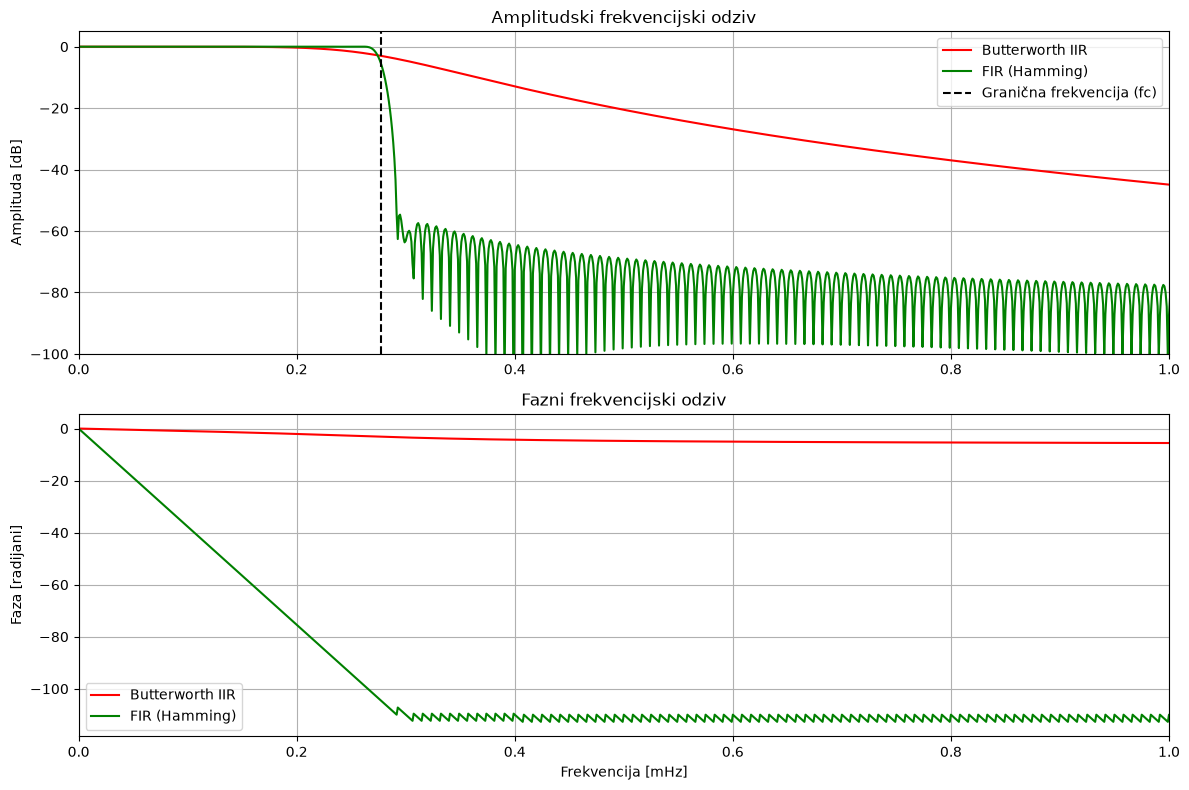

In [20]:
# Generisanje odziva primenom freqz funkcije
w_butter, h_butter = signal.freqz(b_butter, a_butter, worN=8000)
freqs_butter = (w_butter * fs) / (2 * np.pi)

w_fir, h_fir = signal.freqz(fir_coeffs, 1.0, worN=8000)
freqs_fir = (w_fir * fs) / (2 * np.pi)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Amplitudski odziv
ax1.plot(freqs_butter * 1000, 20 * np.log10(np.abs(h_butter)), label='Butterworth IIR', color='red')
ax1.plot(freqs_fir * 1000, 20 * np.log10(np.abs(h_fir)), label='FIR (Hamming)', color='green')
ax1.axvline(fc * 1000, color='black', linestyle='--', label='Granična frekvencija (fc)')
ax1.set_title("Amplitudski frekvencijski odziv")
ax1.set_ylabel("Amplituda [dB]")
ax1.set_xlim(0, 1.0) # Zum na propusni i početak nepropusnog opsega
ax1.set_ylim(-100, 5)
ax1.legend()
ax1.grid(True)

# Fazni odziv
ax2.plot(freqs_butter * 1000, np.unwrap(np.angle(h_butter)), label='Butterworth IIR', color='red')
ax2.plot(freqs_fir * 1000, np.unwrap(np.angle(h_fir)), label='FIR (Hamming)', color='green')
ax2.set_title("Fazni frekvencijski odziv")
ax2.set_xlabel("Frekvencija [mHz]")
ax2.set_ylabel("Faza [radijani]")
ax2.set_xlim(0, 1.0)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 8. Filtriranje signala i poređenje rezultata u vremenskom domenu

Sada primenjujemo dizajnirane filtere na originalni signal pomoću funkcije `signal.lfilter`.
Iako se u praksi za signal ovog tipa fazna pomeranja IIR filtera mogu rešiti korišćenjem "zero-phase" filtriranja (`filtfilt`), ovde koristimo `lfilter` za oba slučaja u svrhe eksperimentalnog demonstriranja faznog uticaja (grupnog kašnjenja) koje bi filteri ostvarili u simulaciji realnog vremena.

Kod FIR filtera linearna faza uvodi jasno determinisano grupno kašnjenje:
$$D = \frac{N - 1}{2}$$

In [13]:
# Filtriranje Butterworth IIR filterom
x_iir_filtered = signal.lfilter(b_butter, a_butter, x_noisy)

# Filtriranje FIR filterom
x_fir_filtered = signal.lfilter(fir_coeffs, 1.0, x_noisy)

# Kompenzacija grupnog kašnjenja radi poštenog poređenja u vremenskom domenu.
# FIR ima linearnu fazu, pa se izlaz samo pomera unapred za (N-1)/2 odbiraka.
fir_delay_samples = (numtaps - 1) // 2
x_fir_aligned = np.concatenate([
    x_fir_filtered[fir_delay_samples:],
    np.full(fir_delay_samples, np.nan)
])
fir_delay_minutes = fir_delay_samples

print(f"Grupno kašnjenje FIR filtera: {fir_delay_samples} odbiraka (što odgovara {fir_delay_minutes} minuta)")

Grupno kašnjenje FIR filtera: 1000 odbiraka (što odgovara 1000 minuta)


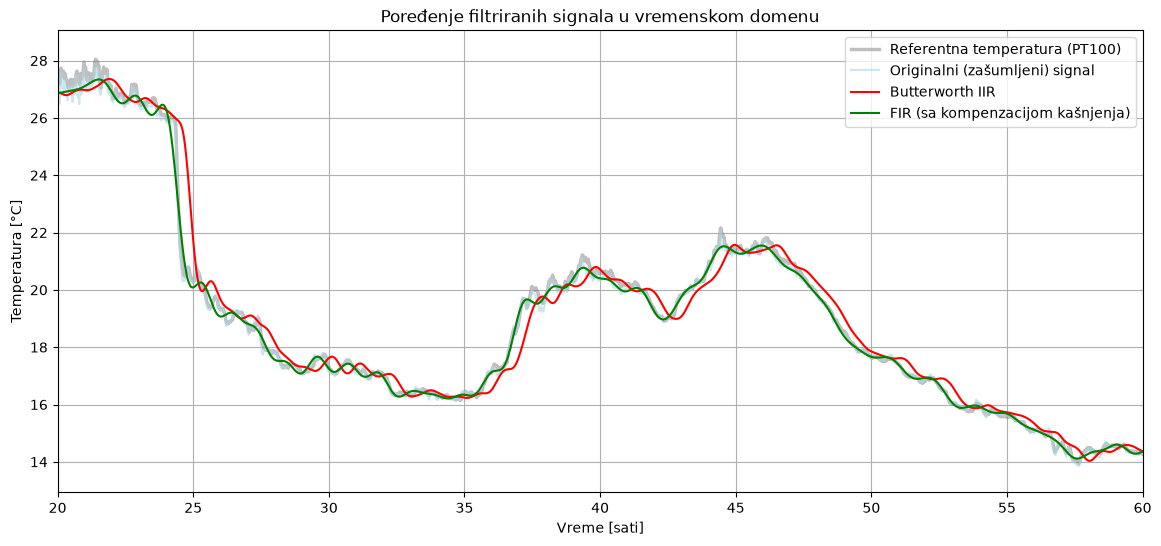

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(t_hours, x_ref, label='Referentna temperatura (PT100)', color='gray', alpha=0.5, linewidth=2.5)
plt.plot(t_hours, x_noisy, label='Originalni (zašumljeni) signal', color='lightblue', alpha=0.6)
plt.plot(t_hours, x_iir_filtered, label='Butterworth IIR', color='red', linewidth=1.5)
plt.plot(t_hours, x_fir_aligned, label='FIR (sa kompenzacijom kašnjenja)', color='green', linewidth=1.5)

plt.title("Poređenje filtriranih signala u vremenskom domenu")
plt.xlabel("Vreme [sati]")
plt.ylabel("Temperatura [°C]")

# Zum na specifičan vremenski prozor kako bi se lepo video i trend i kašnjenje.
plt.xlim(20, 60)
plt.ylim(np.min(x_ref[1200:3600]) - 1, np.max(x_ref[1200:3600]) + 1)
plt.legend()
plt.show()

## 9. Poređenje u frekvencijskom domenu

FFT analizom filtriranih izlaza proveravamo do koje mere je potisnut neželjeni šum iznad granične frekvencije. Prikazan je amplitudski spektar, koji je dovoljno informativan za poređenje potiskivanja šuma.

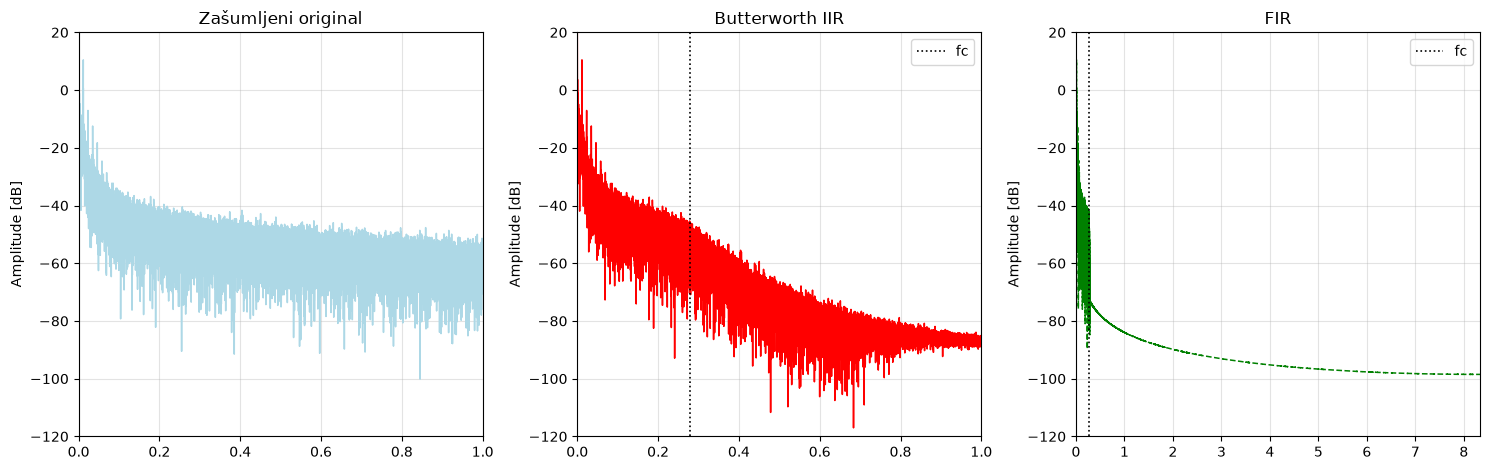

In [15]:
# FFT analiza IIR i FIR rezultata
X_iir_fft = fft(x_iir_filtered)
X_fir_fft = fft(x_fir_filtered)

amp_iir_pos = np.abs(X_iir_fft)[pos_mask] * 2.0 / N
amp_fir_pos = np.abs(X_fir_fft)[pos_mask] * 2.0 / N

# Pregledniji prikaz: amplituda je data u dB, a svaki signal je u svom podgrafiku
# kako se krive ne bi preklapale i skrivale relevantne detalje.
amp_floor = 1e-6
to_db = lambda amplitude: 20.0 * np.log10(np.maximum(amplitude, amp_floor))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=False)

# Amplitudski spektar
axes[0].plot(freqs_pos * 1000, to_db(amp_noisy_pos), color='lightblue', linewidth=1.1)
axes[0].set_title("Zašumljeni original")
axes[0].set_ylabel("Amplitude [dB]")
axes[0].set_xlim(0, 1.0)
axes[0].set_ylim(-120, 20)
axes[0].grid(True, alpha=0.35)

axes[1].plot(freqs_pos * 1000, to_db(amp_iir_pos), color='red', linewidth=1.1)
axes[1].axvline(fc * 1000, color='black', linestyle=':', linewidth=1.2, label='fc')
axes[1].set_title("Butterworth IIR")
axes[1].set_ylabel("Amplitude [dB]")
axes[1].set_xlim(0, 1.0)
axes[1].set_ylim(-120, 20)
axes[1].grid(True, alpha=0.35)
axes[1].legend(loc='upper right')

axes[2].plot(freqs_pos * 1000, to_db(amp_fir_pos), color='green', linewidth=1.1, linestyle='--')
axes[2].axvline(fc * 1000, color='black', linestyle=':', linewidth=1.2, label='fc')
axes[2].set_title("FIR")
axes[2].set_ylabel("Amplitude [dB]")
axes[2].set_xlim(0, np.max(freqs_pos * 1000))
axes[2].set_ylim(-120, 20)
axes[2].grid(True, alpha=0.35)
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

In [16]:
# Numerička provera kvaliteta filtriranja u odnosu na referentni signal.
# Zbog FIR grupnog kašnjenja poređenje radimo na zajedničkom intervalu bez početnog i završnog tranzijenta.
analysis_start = fir_delay_samples
analysis_end = N - fir_delay_samples

if analysis_end <= analysis_start:
    analysis_start = 0
    analysis_end = N

x_ref_eval = x_ref[analysis_start:analysis_end]
x_noisy_eval = x_noisy[analysis_start:analysis_end]
x_iir_eval = x_iir_filtered[analysis_start:analysis_end]
x_fir_eval = x_fir_aligned[analysis_start:analysis_end]

def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def corr(a, b):
    if len(a) < 2:
        return np.nan
    return np.corrcoef(a, b)[0, 1]

# IIR poravnavamo prema referenci pomoću unakrsne korelacije, kako fazni pomak ne bi dominirao metrikama.
iir_corr = signal.correlate(x_iir_eval - np.mean(x_iir_eval), x_ref_eval - np.mean(x_ref_eval), mode='full')
iir_lag = np.argmax(iir_corr) - (len(x_ref_eval) - 1)

if iir_lag > 0:
    x_iir_metric = x_iir_eval[iir_lag:]
    x_ref_metric_iir = x_ref_eval[:len(x_iir_metric)]
elif iir_lag < 0:
    x_ref_metric_iir = x_ref_eval[-iir_lag:]
    x_iir_metric = x_iir_eval[:len(x_ref_metric_iir)]
else:
    x_iir_metric = x_iir_eval
    x_ref_metric_iir = x_ref_eval

x_ref_metric_fir = x_ref_eval[:len(x_fir_eval)]
x_fir_metric = x_fir_eval
x_ref_metric_noisy = x_ref_eval
x_noisy_metric = x_noisy_eval

metrics = pd.DataFrame(
    {
        "Signal": ["Zašumljeni", "IIR (poravnat)", "FIR (poravnat)"],
        "RMSE": [rmse(x_noisy_metric, x_ref_metric_noisy), rmse(x_iir_metric, x_ref_metric_iir), rmse(x_fir_metric, x_ref_metric_fir)],
        "MAE": [mae(x_noisy_metric, x_ref_metric_noisy), mae(x_iir_metric, x_ref_metric_iir), mae(x_fir_metric, x_ref_metric_fir)],
        "Korelacija": [corr(x_noisy_metric, x_ref_metric_noisy), corr(x_iir_metric, x_ref_metric_iir), corr(x_fir_metric, x_ref_metric_fir)],
    }
)

roughness = pd.DataFrame(
    {
        "Signal": ["Zašumljeni", "IIR", "FIR"],
        "Std(dif)": [
            np.std(np.diff(x_noisy_metric)),
            np.std(np.diff(x_iir_metric)),
            np.std(np.diff(x_fir_metric)),
        ],
    }
)

print("Numeričko poređenje sa referentnim signalom na zajedničkom intervalu:")
print(f"Procenjeni pomak IIR signala: {iir_lag} odbiraka")
print(metrics.to_string(index=False, float_format=lambda value: f"{value:.4f}"))
print("\nMera glatkosti signala (niže vrednosti znače manje visokofrekventnih promena):")
print(roughness.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

Numeričko poređenje sa referentnim signalom na zajedničkom intervalu:
Procenjeni pomak IIR signala: 25 odbiraka
        Signal   RMSE    MAE  Korelacija
    Zašumljeni 0.2028 0.1243      0.9998
IIR (poravnat) 0.2090 0.1287      0.9998
FIR (poravnat) 0.2242 0.1405      0.9997

Mera glatkosti signala (niže vrednosti znače manje visokofrekventnih promena):
    Signal  Std(dif)
Zašumljeni    0.0966
       IIR    0.0210
       FIR    0.0207


## 9.1 Diskusija

U ovoj analizi je posebno važna perioda odabiranja od jedne minute. Ona određuje frekvencijski opseg koji signal može da predstavi bez aliasinga i objašnjava zašto cutoff ne može da bude proizvoljno visok. Kada je cutoff previše visok, filter praktično ne uklanja šum; kada je suviše nizak, počinje da potiskuje i korisni temperaturni trend.

- Vremenska osa je vezana za stvarne vremenske oznake iz CSV fajla, umesto da bude izvedena samo iz broja uzoraka.
- Korak uzorkovanja je proveren, jer prekid ili skok u vremenskoj seriji utiče i na FFT i na filtriranje.
- Butterworth je izabran zbog jednostavnog i glatkog odziva, ali nosi fazni pomak.
- FIR je izabran zbog linearne faze, ali uvodi veliko grupno kašnjenje i zahteva veći red.
- Numerička provera preko RMSE, MAE i korelacije dopunjuje vizuelno poređenje, pa zaključci nisu zasnovani samo na grafikonima.

## 10. Zaključak

Nakon sprovedene analize možemo doneti konačne zaključke o performansama:

1. **Efikasnost uklanjanja šuma:** Oba digitalna filtera veoma efikasno potiskuju neželjene visokofrekventne fluktuacije merenja u radijacionim kućištima, što se vidi i na FFT spektrima, a dodatno potvrđuju i numeričke metrike iz prethodne ćelije.
2. **Očuvanje dnevnog temperaturnog trenda:** Niskofrekventna priroda glavnog signala očuvana je do granične frekvencije i nije amplitudski ublažena.
3. **Razlike u faznom odzivu i grupnom kašnjenju:** IIR filter je računarski jednostavniji, ali mu je faza nelinearna, pa pri naglim promenama temperature uvodi fazno izobličenje. S druge strane, FIR filter postiže linearnu fazu po cenu većeg reda i znatnog kašnjenja, zbog čega je u vremenskom domenu prethodno poravnat.

## 11. Literatura

- Tehničke specifikacije projekta - zahtevi za realizaciju.
- Skup podataka `temperature_measurements_2025.csv` - minutna merenja iz radijacionih kućišta (Zenodo DOI: 10.5281/zenodo.18407465).
- Literaturni primeri sa računarskih vežbi iz predmeta Primena DSP u upravljanju.